In [1]:
import os
import pandas as pd
import random
import shutil

data_path = r'C:\Users\chloe\OneDrive\Desktop\swallow EMG\data\participants\1\extracted signals'

In [2]:
os.chdir("..") 

from src import feature_extraction, models, utils, results

exclude = ['oral prep 0']
df, class_map = feature_extraction.make_df(data_path, exclude)

df

substance volume         1                                              \
                           min       max        mav        rms    variance   
0           0     10  -89.8215   73.5244  10.123081  15.526914  241.085047   
1           0     10 -113.9200   86.1073   9.896790  16.791919  281.968302   
2           0     10  -82.3953   84.7438  10.532140  16.572327  274.641479   
3           0     10 -194.0030  125.6940  11.846242  20.842131  434.394440   
4           0     10 -117.7260   84.5021  11.854229  18.994828  360.801618   
..        ...    ...       ...       ...        ...        ...         ...   
440        10     20  -69.3289   69.5755  10.175371  15.426147  237.965865   
441        10     20  -86.3076   74.0248  11.288252  18.020237  324.728936   
442        10     20  -93.5527   91.9620  11.081596  17.163182  294.572930   
443        10     20  -95.3684   61.4933  11.031382  16.758005  280.830702   
444        10     20  -95.7571   91.9919  13.782139  20.737838  430.057924   

                                    ...            22                 \
     ssc     abs_diffs total_power  ...      variance  ssc abs_diffs   
0    432   8511.370464  307.637873  ...  2.147730e+07  130    426580   
1    440   8262.519721  347.467667  ...  2.476357e+07  117    449540   
2    427   8938.223938  335.785845  ...  3.078873e+07  147    391580   
3    432   9634.231501  503.956192  ...  4.119861e+07   94    458780   
4    394   9543.440074  450.438358  ...  4.449073e+07  121    353780   
..   ...           ...         ...  ...           ...  ...       ...   
440  396   8874.451929  312.405973  ...  1.854732e+07   95    329560   
441  421   9792.563997  432.794002  ...  2.879051e+07  137    396620   
442  417   8838.968969  368.683906  ...  2.811149e+07  109    390740   
443  390   9634.328738  345.837883  ...  2.616131e+07   90    390040   
444  403  11234.928474  547.324652  ...  2.290177e+07  120    462560   

                                                                \
      total_power     iemg shannon_entropy mean_freq peak_freq   
0    2.855146e+07  3322060        4.040291  7.067688       2.0   
1    2.839299e+07  4038860        4.537548  5.096151       1.0   
2    2.837819e+07  4577860        4.487950  4.361224       1.0   
3    2.361374e+07  5437880        4.410476  8.145964      13.0   
4    3.530921e+07  5531540        4.641191  3.729602       1.0   
..            ...      ...             ...       ...       ...   
440  2.012949e+07  3136980        3.997013  5.815702       3.0   
441  3.994745e+07  3865400        4.062512  5.177273       2.0   
442  3.174081e+07  4293940        4.641988  4.827547       3.0   
443  3.482336e+07  3813460        4.344892  5.345078       2.0   
444  2.527296e+07  3783080        4.518855  5.978335       3.0   

                                     
    spectral_edge_freq crest_factor  
0                 17.0     3.383382  
1                 16.0     2.549675  
2                 15.0     2.601074  
3                 16.0     3.326772  
4                 14.0     2.306773  
..                 ...          ...  
440               15.0     4.349148  
441               13.0     4.329699  
442               14.0     2.561073  
443               14.0     3.117836  
444               15.0     2.974145  

[445 rows x 310 columns]

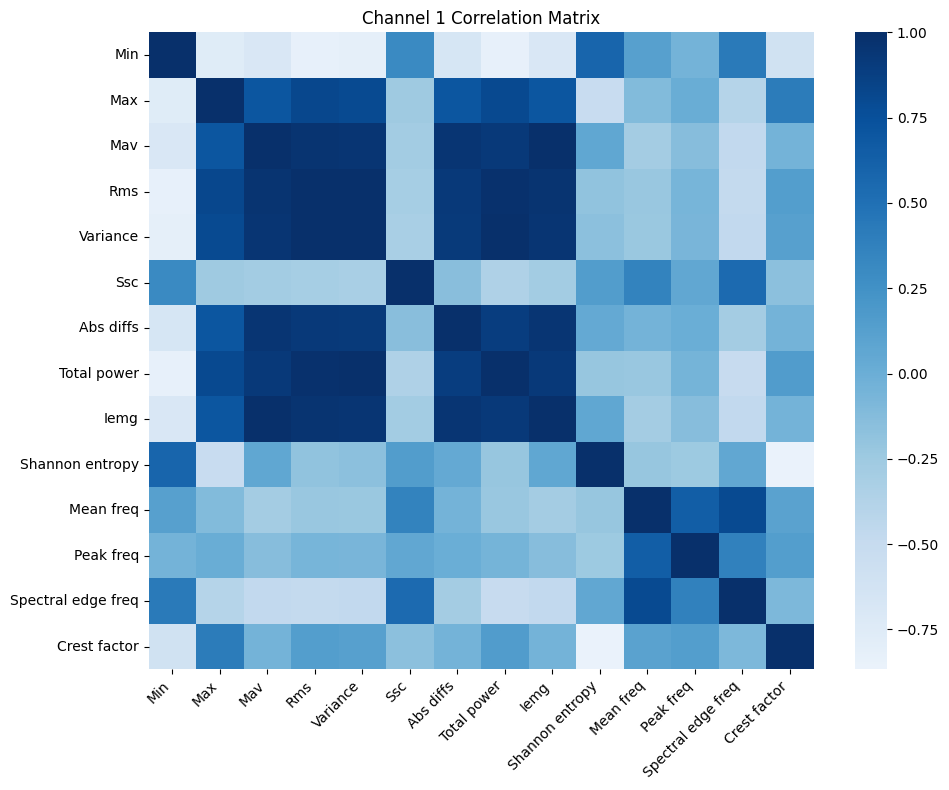

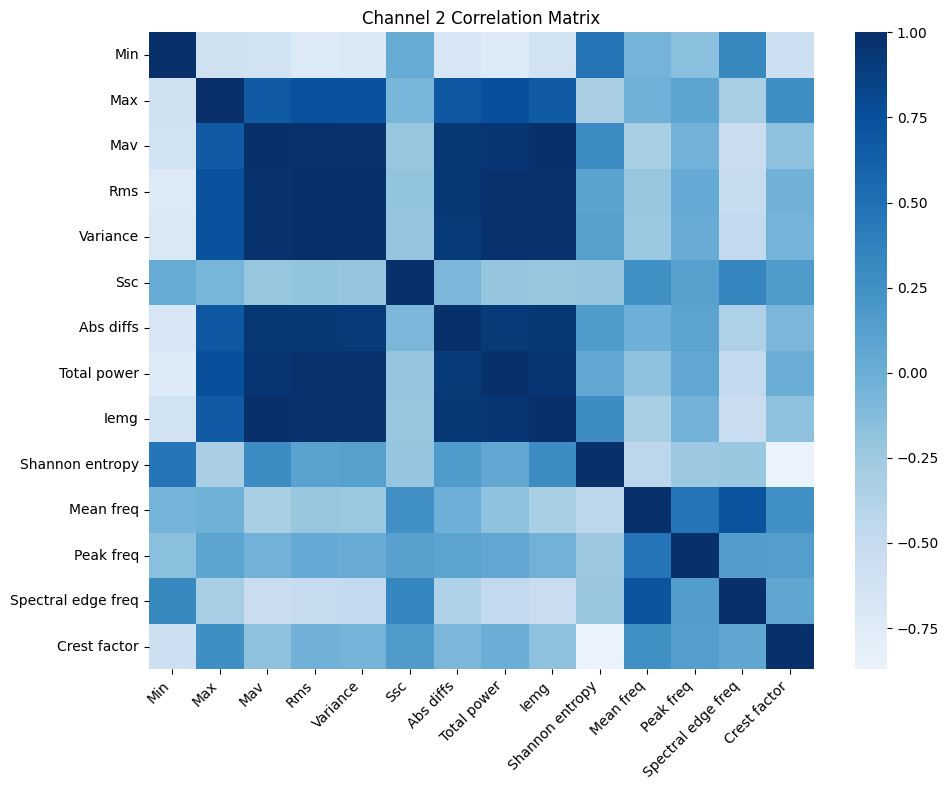

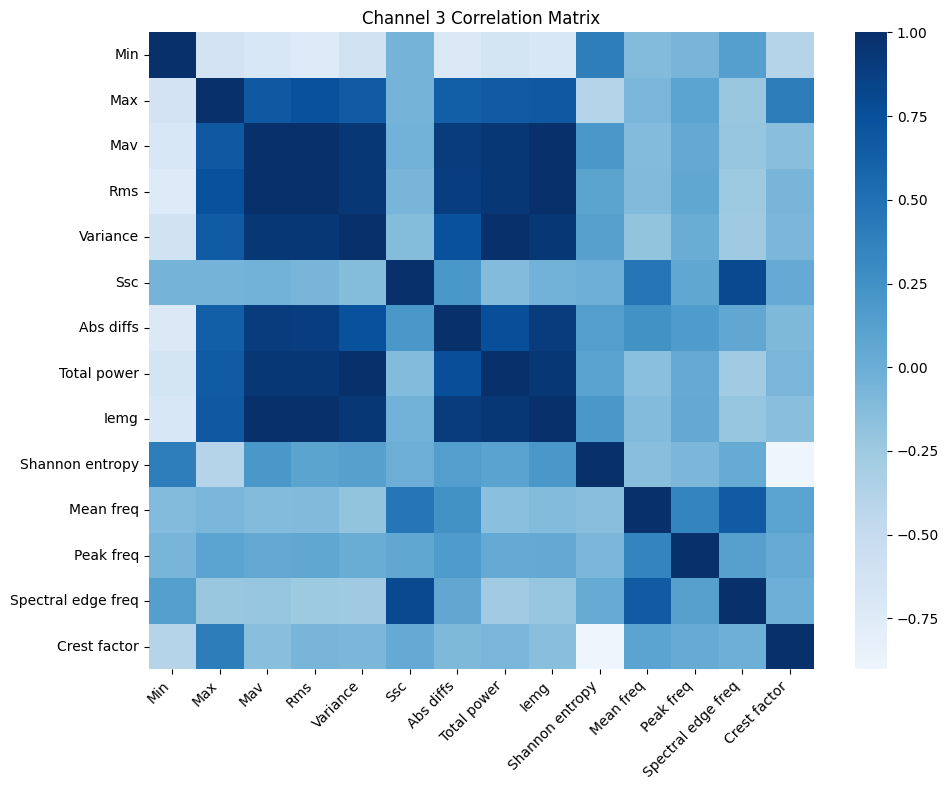

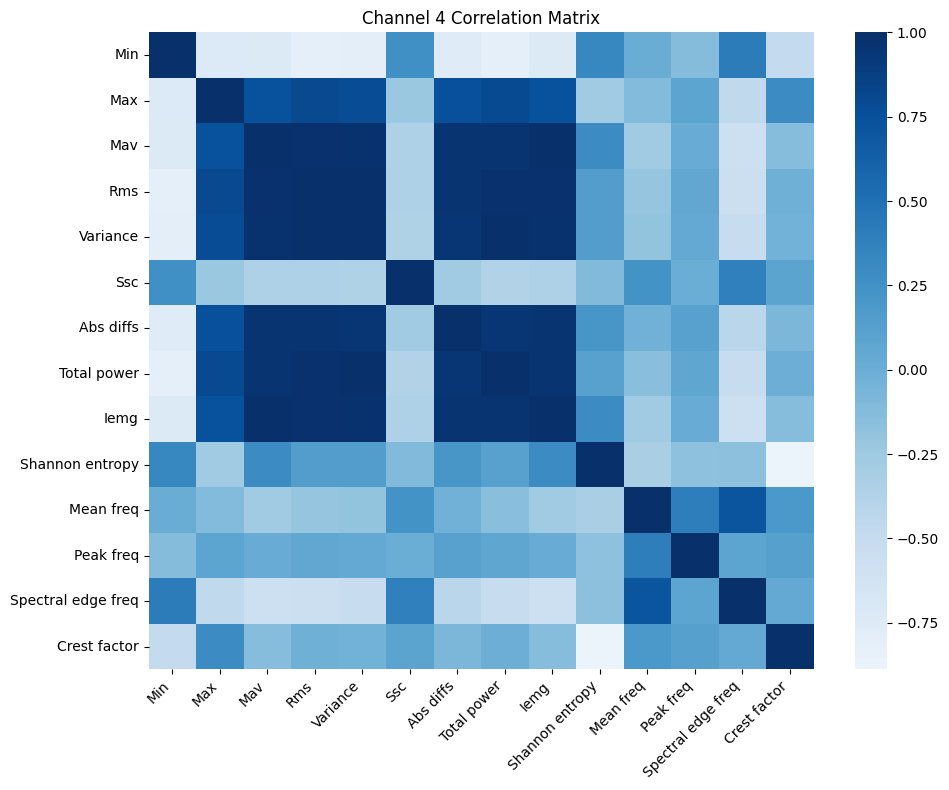

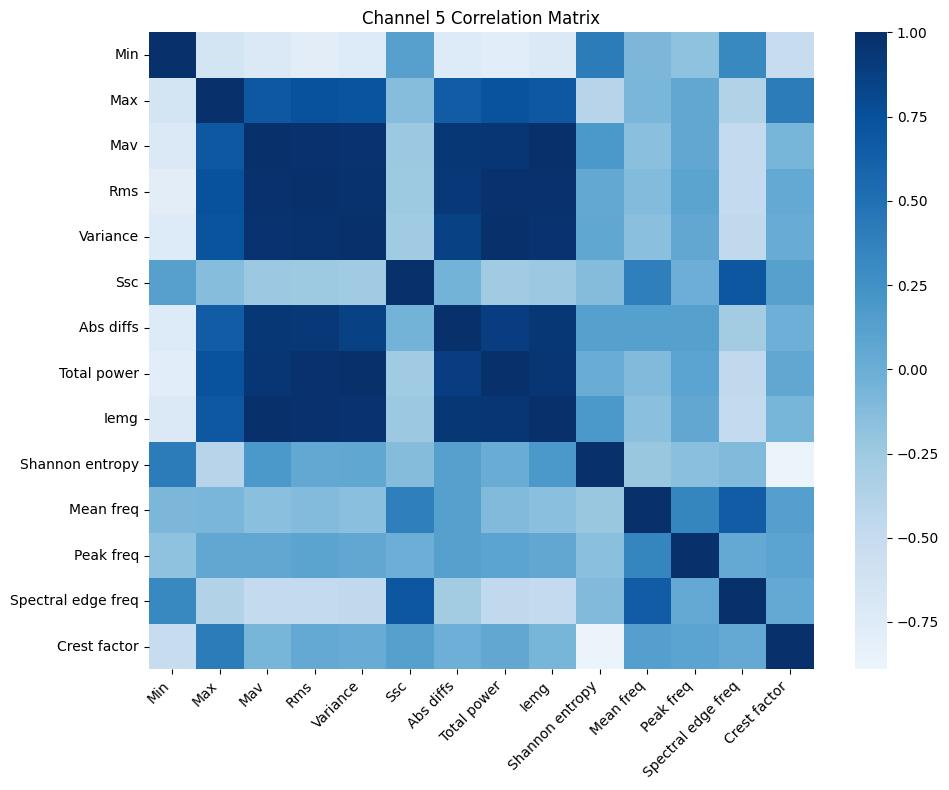

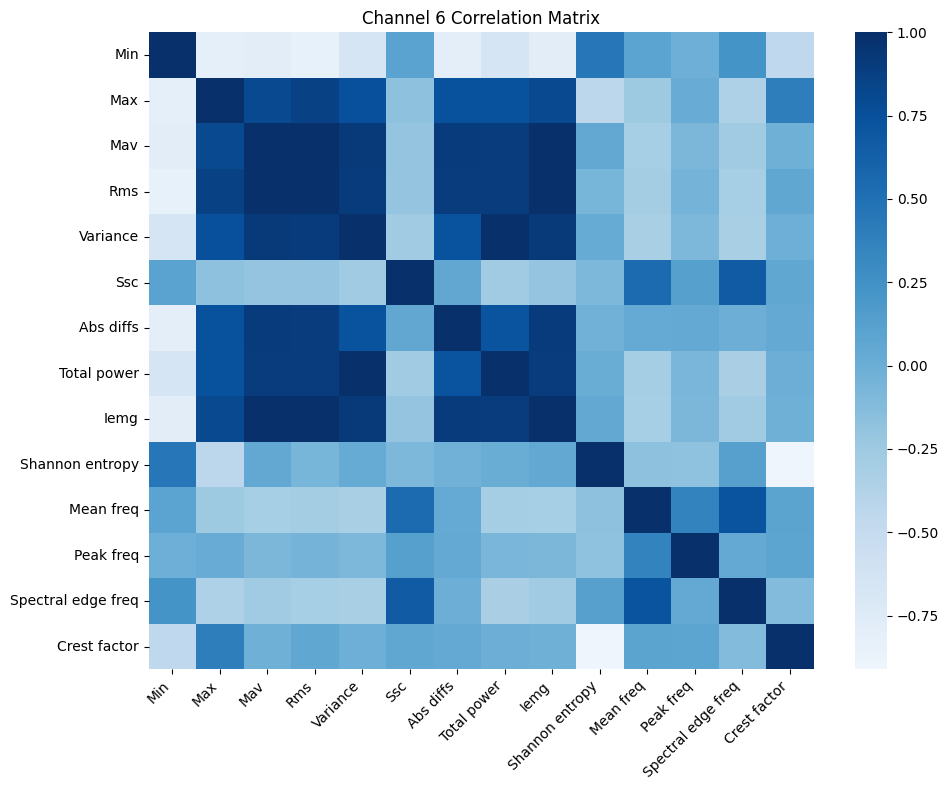

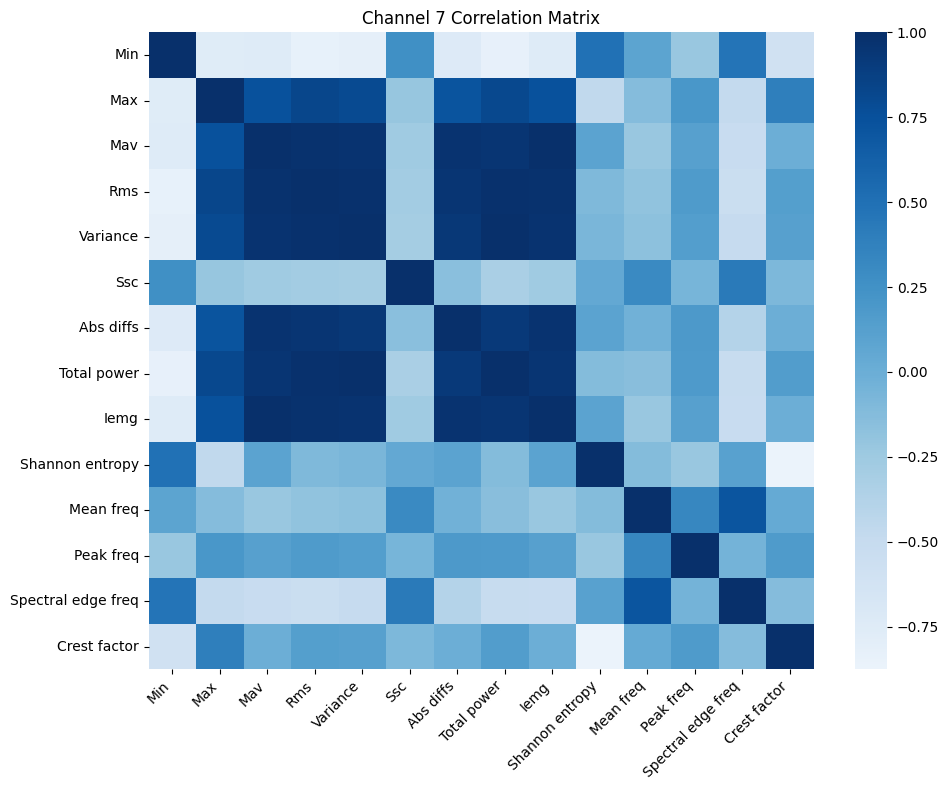

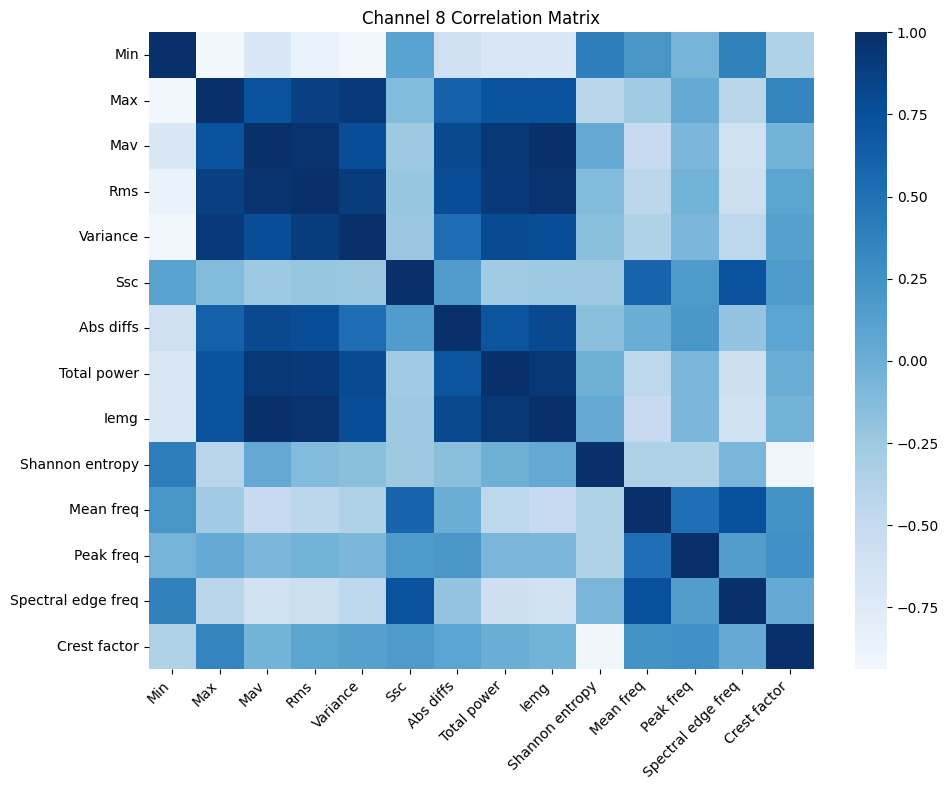

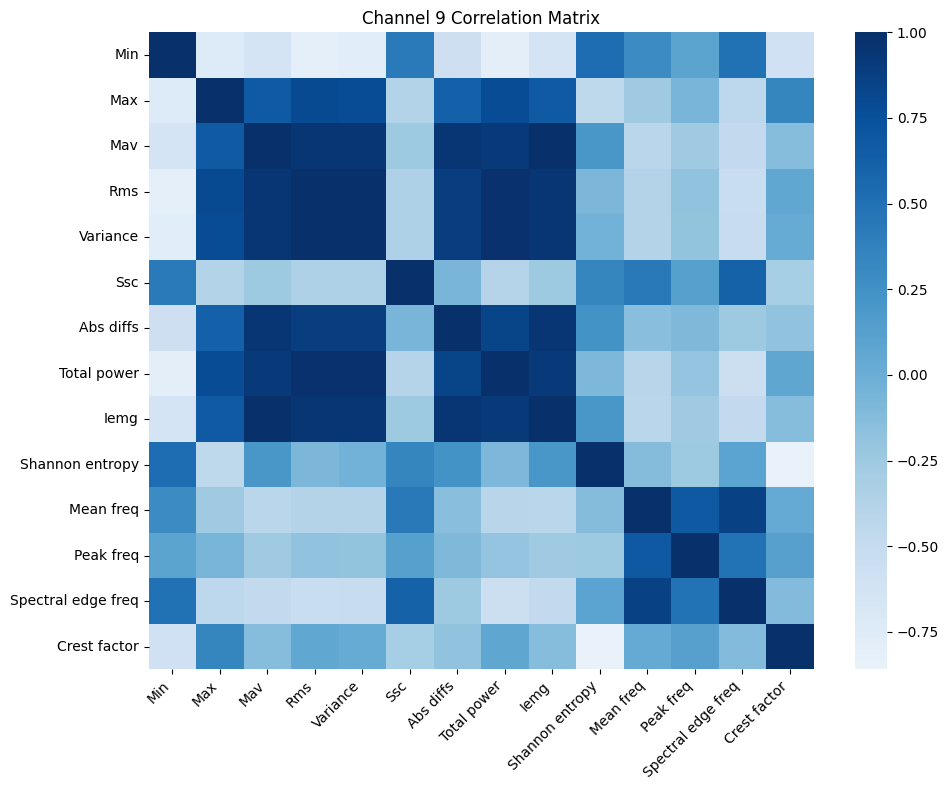

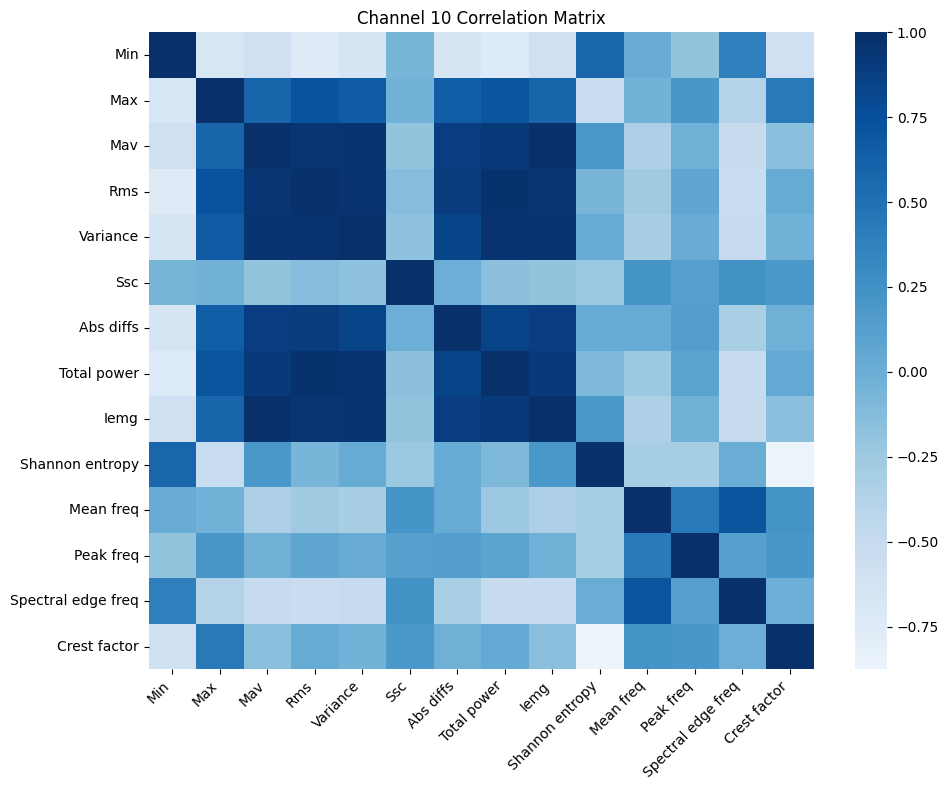

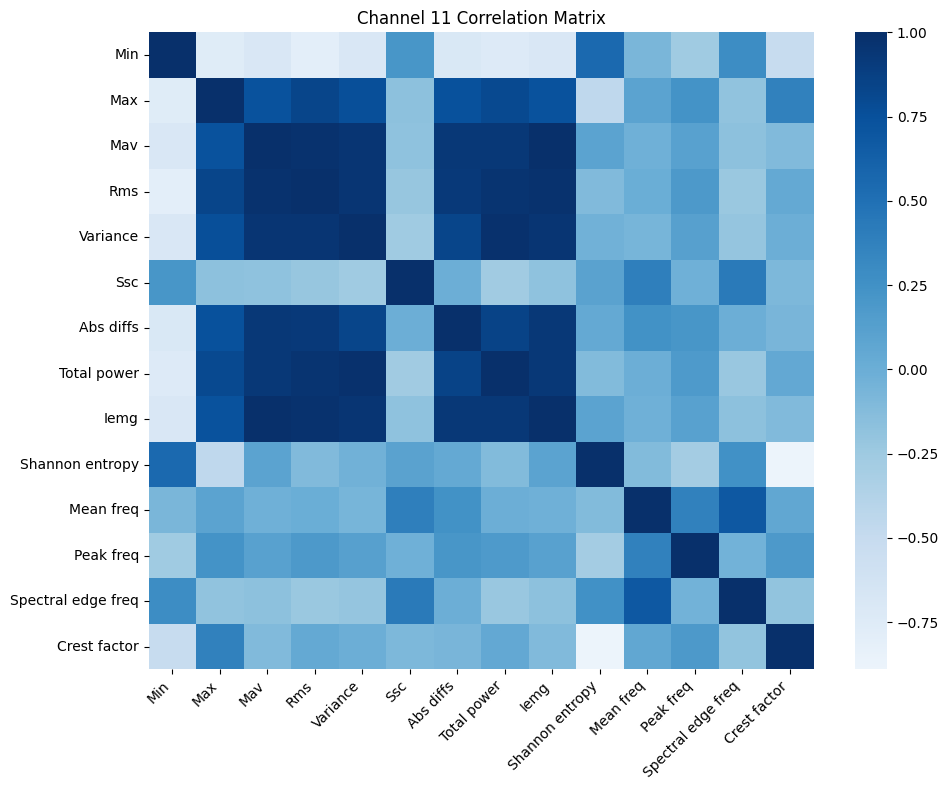

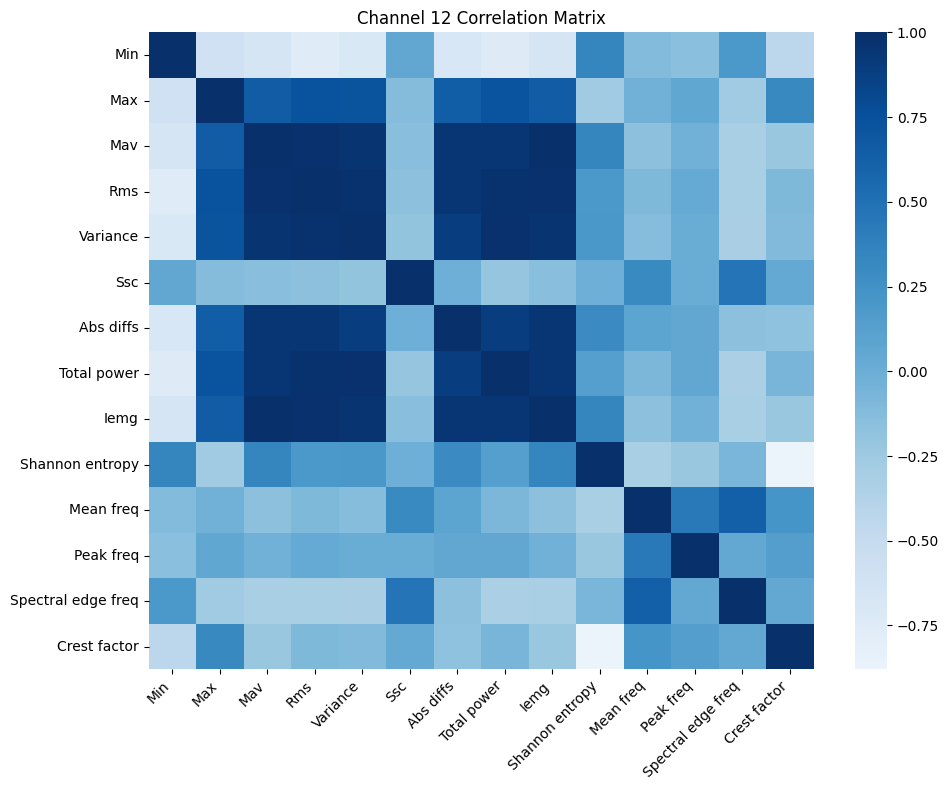

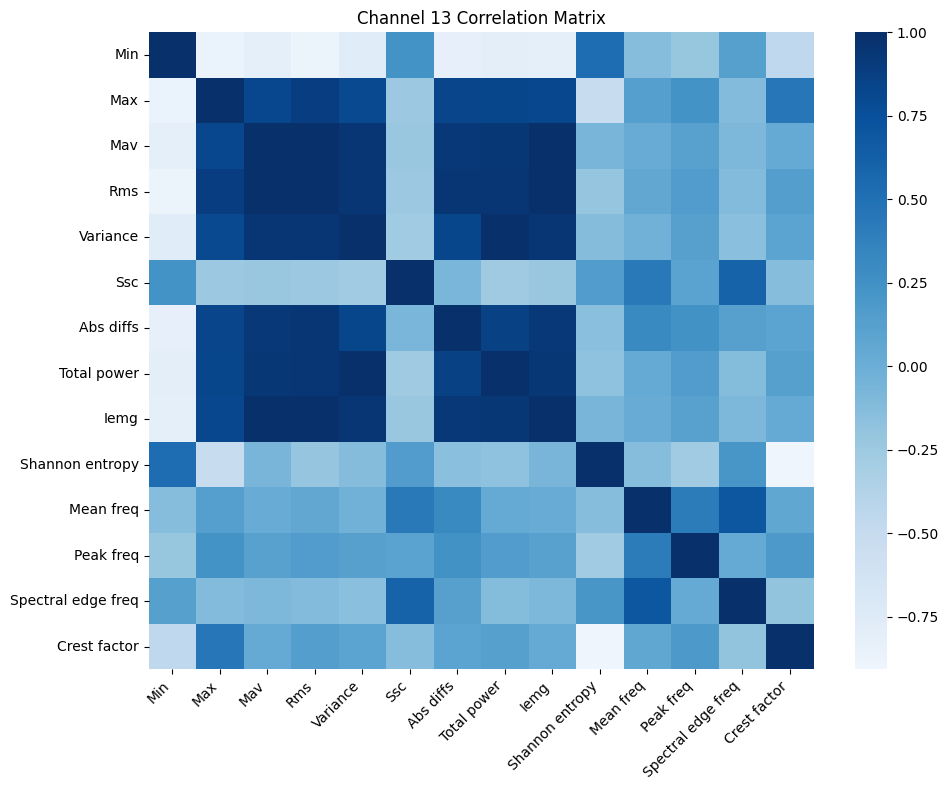

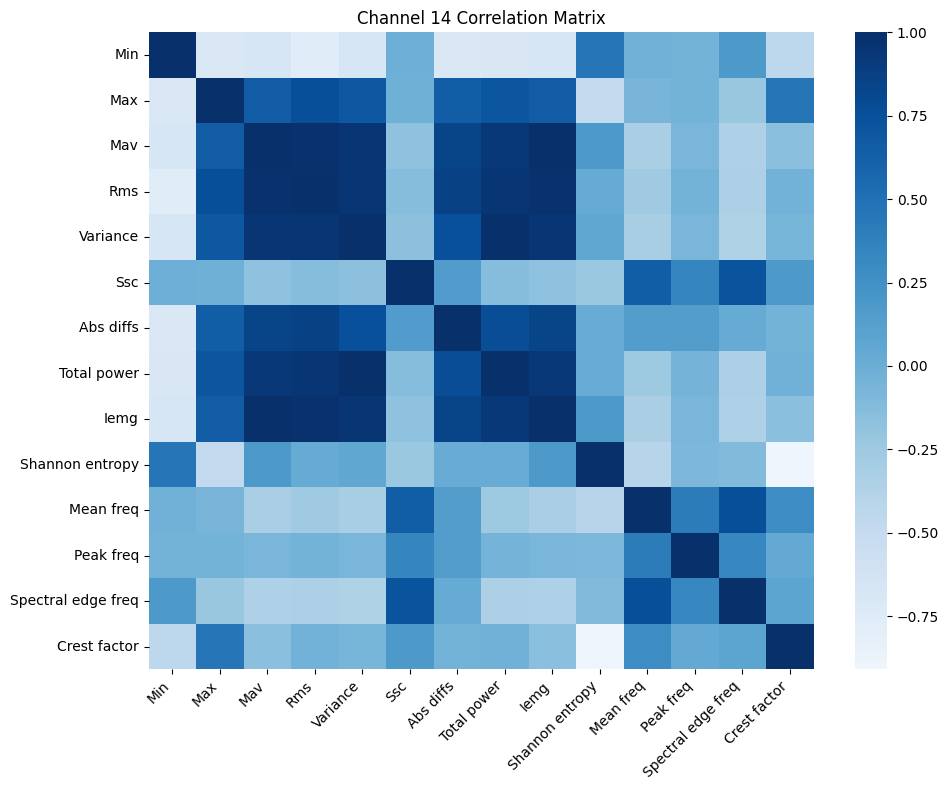

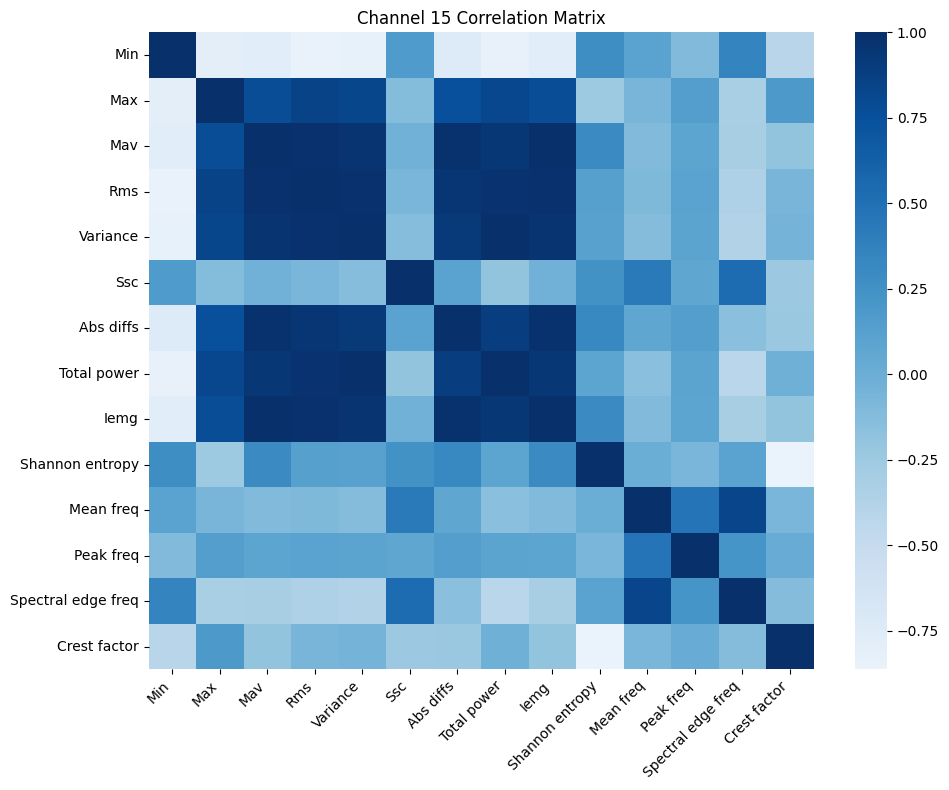

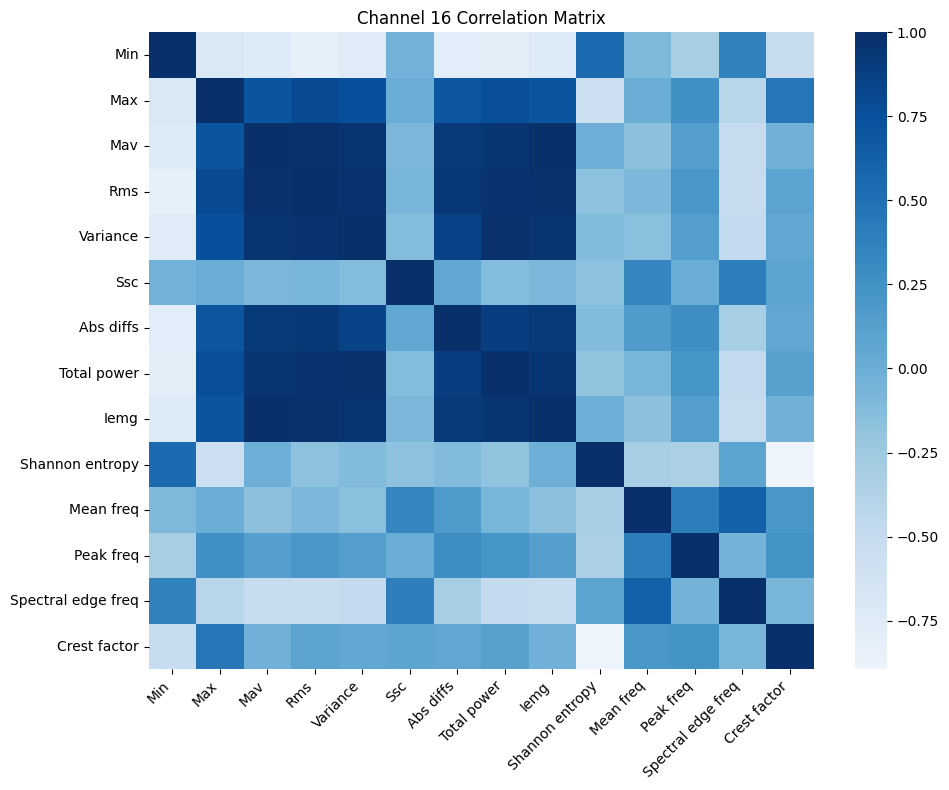

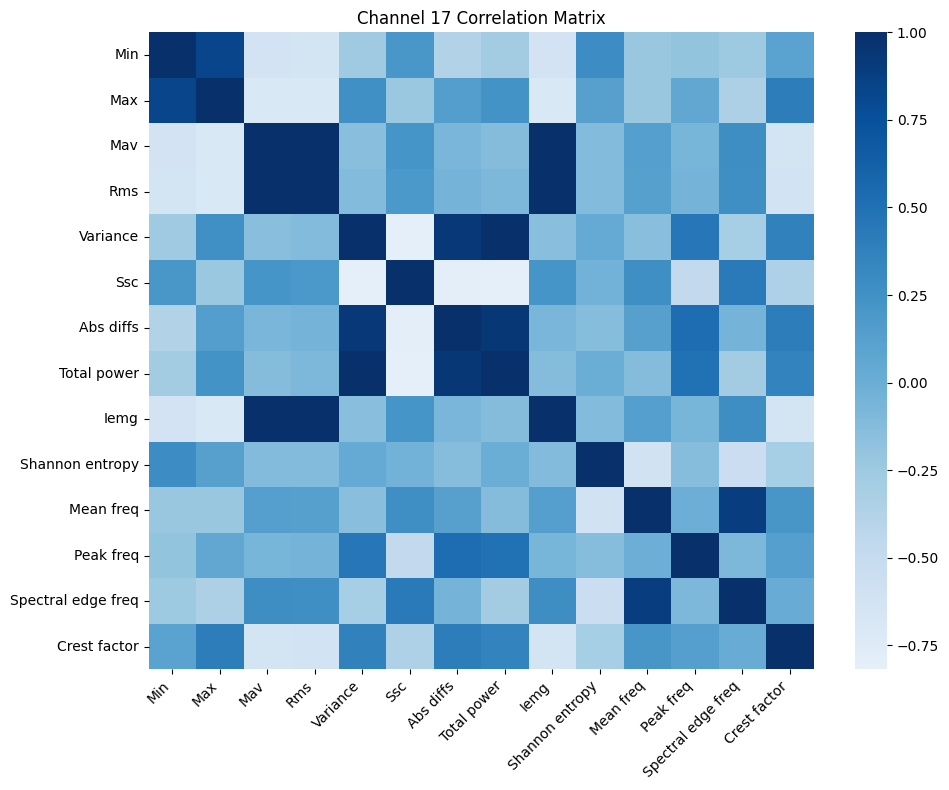

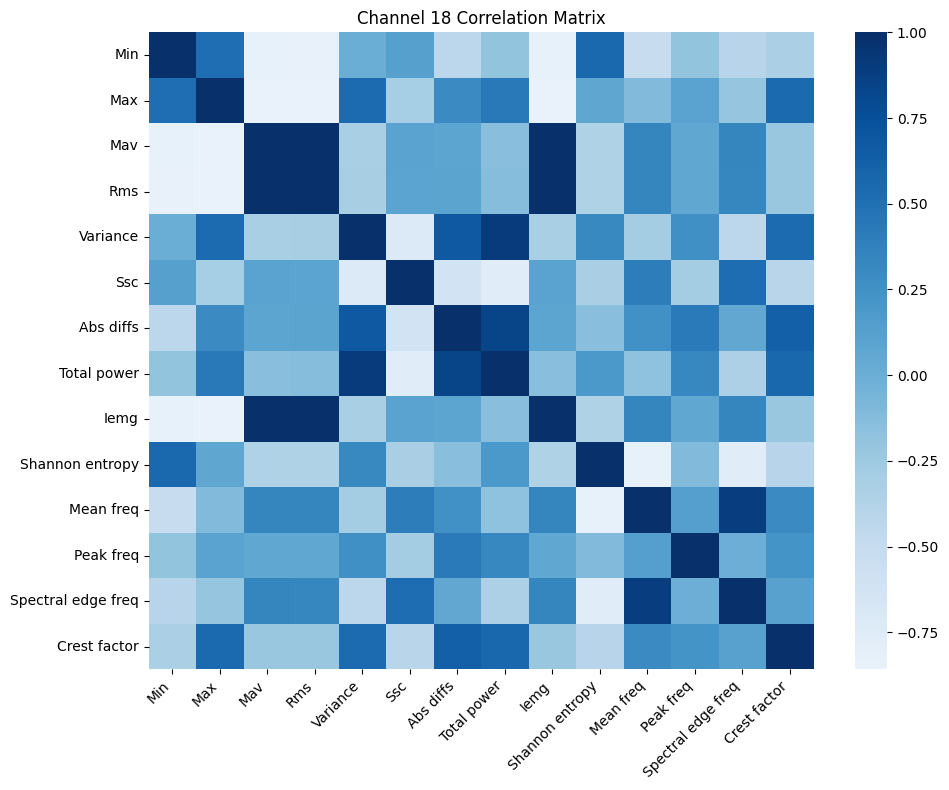

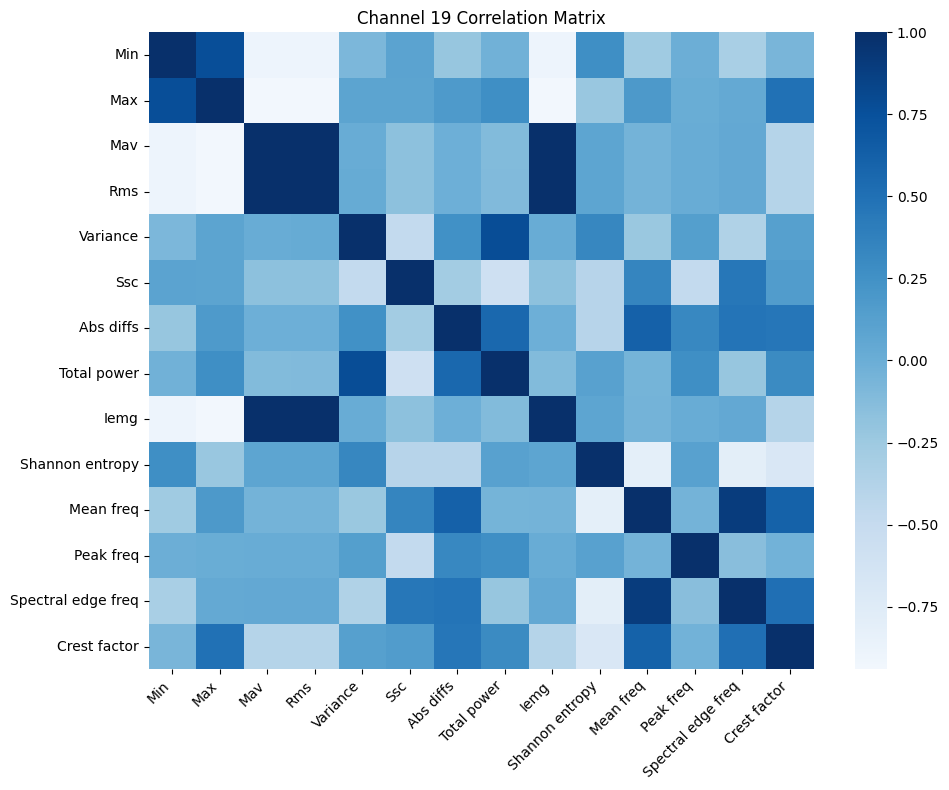

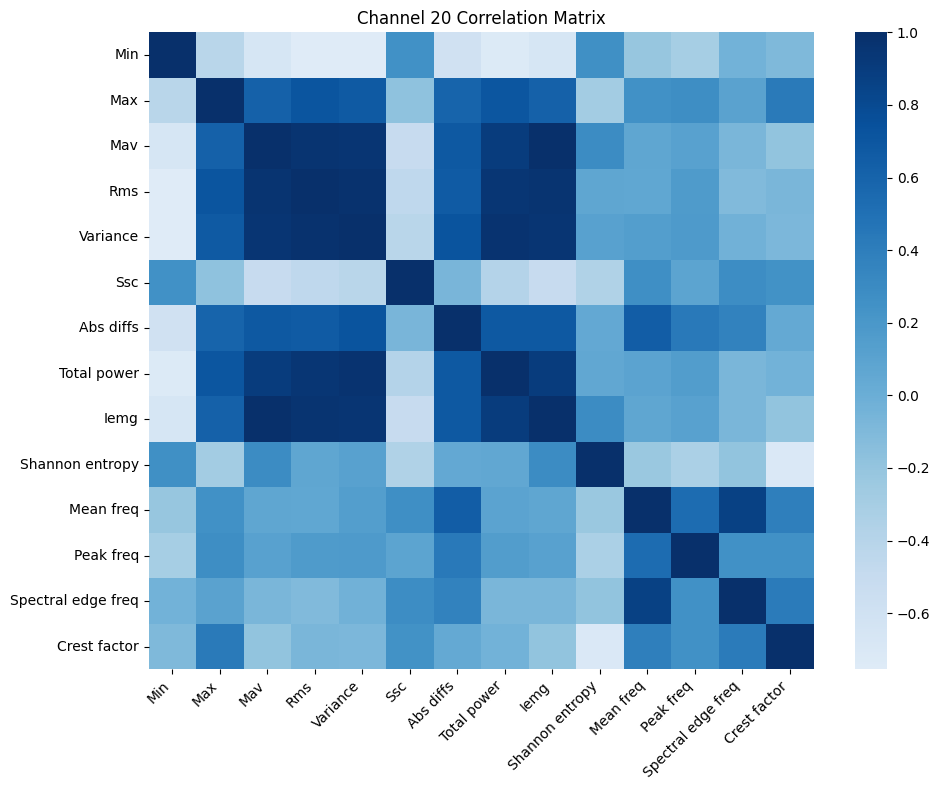

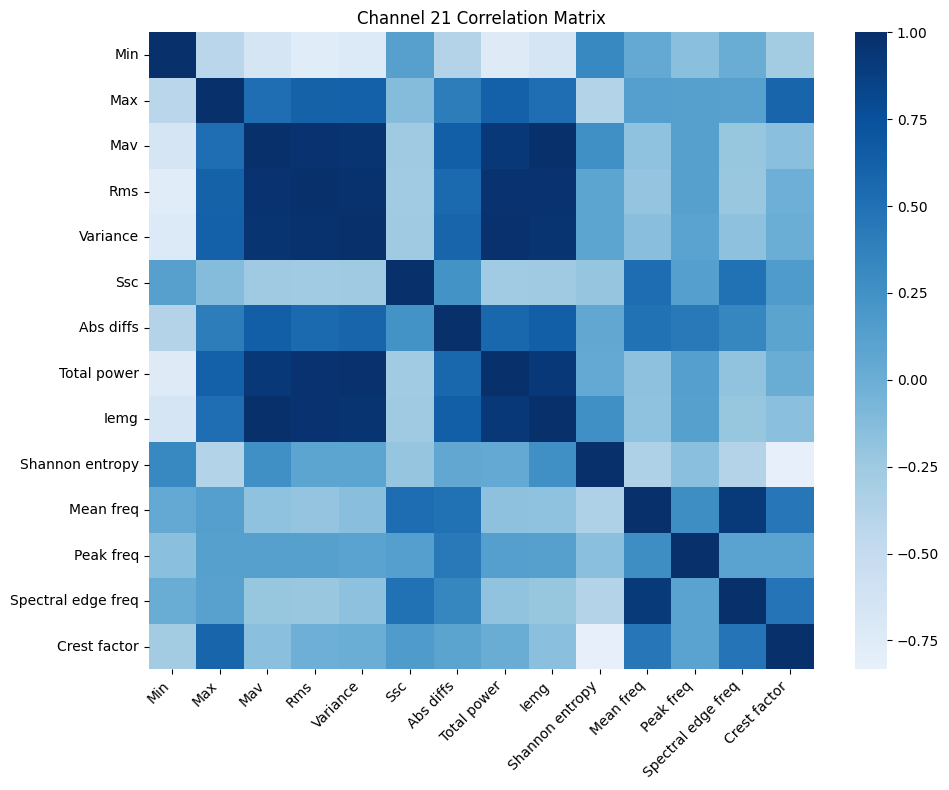

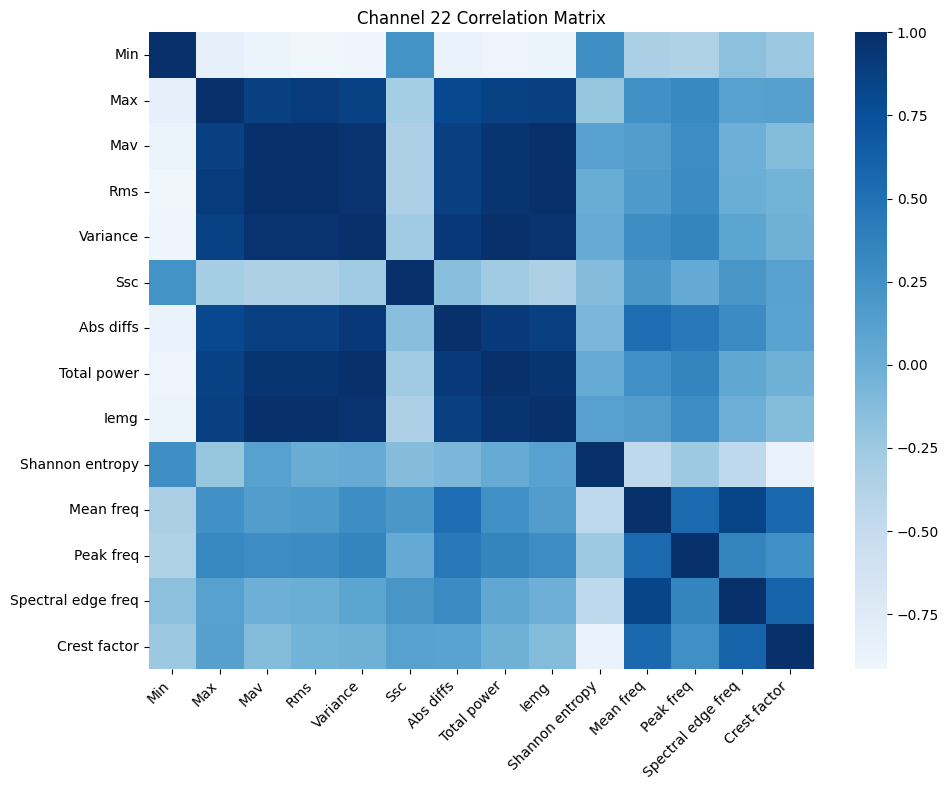

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def format_feature_name(name):
    return name.replace('_', ' ').capitalize()

num_features = 14

for i in range(22):
    channel_df = df.iloc[:, i*num_features+2:i*num_features+num_features+2]
    channel_df.columns = channel_df.columns.get_level_values(1)
    corr = channel_df.corr()

    formatted_labels = [format_feature_name(name) for name in corr.columns]
    
    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(corr, cmap="Blues", center=0, 
                     xticklabels=formatted_labels, 
                     yticklabels=formatted_labels)
    
    plt.title("Channel " + str(i+1) + " Correlation Matrix")
    plt.xticks(rotation=45, ha='right')  
    plt.yticks(rotation=0) 
    plt.tight_layout()
    plt.show()

# Neural Network Feature Selection

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = df.drop(columns=['volume', 'substance'])
y = df[['substance', 'volume']]

combined_y = y['substance'].astype(str) + '_' + y['volume'].astype(str)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=combined_y, random_state=42)

y_train = y_train.astype(int)
y_test = y_test.astype(int)
    
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

C:\Users\chloe\AppData\Local\Temp\ipykernel_26340\802329423.py:4: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x = df.drop(columns=['volume', 'substance'])


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

x_train_t = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
x_test_t  = torch.tensor(x_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32)

n_features = x_train_scaled.shape[1]
n_outputs  = y_train.shape[1]  

class Net(nn.Module):
    def __init__(self, n_features, n_outputs):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 16)   # first layer (feature importance lives here)
        self.fc2 = nn.Linear(16, n_outputs)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [6]:
feature_names = x_train.columns  

model = Net(n_features, n_outputs)

# Loss + optimizer
criterion = nn.MSELoss()   # if regression
optimizer = optim.Adam(model.parameters(), lr=1e-3)
l1_lambda = 1e-4   # strength of L1 penalty

for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(x_train_t)

    loss = criterion(outputs, y_train_t)

    # add L1 penalty on first layer weights
    l1_penalty = l1_lambda * torch.norm(model.fc1.weight, 1)
    loss = loss + l1_penalty

    loss.backward()
    optimizer.step()

with torch.no_grad():
    weights = model.fc1.weight.abs().mean(dim=0)  # average across hidden units
    importance = weights.numpy()

feature_importance = list(zip(feature_names, importance))
feature_importance_sorted = sorted(feature_importance, key=lambda x: -x[1])

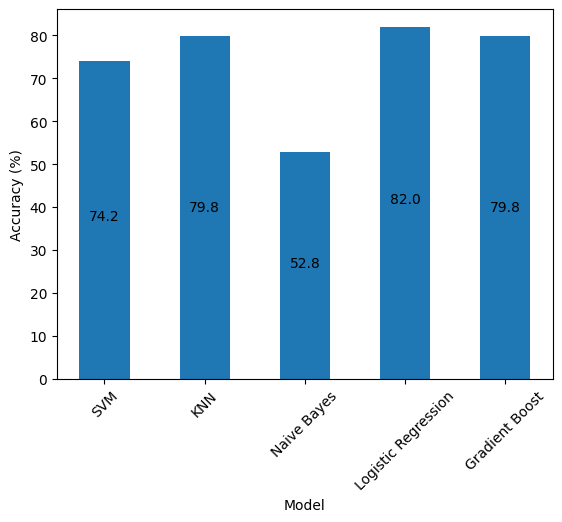

In [7]:
n = 30  
top_features = [f for f, _ in feature_importance_sorted[:n]]

x_reduced = x[top_features].copy()

nn_exact_accuracies, nn_label_accuracies = models.train_multioutput_models(x_reduced, y, class_map, random_state=42, show_cm=False)

results.plot_acc(nn_exact_accuracies)


# No PCA

In [8]:
x = df.drop(columns=['volume', 'substance'])
y = df[['substance', 'volume']]
exact_accuracies, label_accuracies = models.train_multioutput_models(x, y, class_map, random_state=42, show_cm=False, show_metrics=True)

C:\Users\chloe\AppData\Local\Temp\ipykernel_26340\2590886700.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x = df.drop(columns=['volume', 'substance'])


SVM
Exact Match Accuracy: 91.0112
Per-Label Accuracies: [96.62921348 92.13483146]
----------------------------
KNN
Exact Match Accuracy: 84.2697
Per-Label Accuracies: [88.76404494 84.26966292]
----------------------------
Naive Bayes
Exact Match Accuracy: 59.5506
Per-Label Accuracies: [84.26966292 67.41573034]
----------------------------
Logistic Regression
Exact Match Accuracy: 86.5169
Per-Label Accuracies: [96.62921348 89.88764045]
----------------------------
Gradient Boost
Exact Match Accuracy: 80.8989
Per-Label Accuracies: [89.88764045 86.51685393]
----------------------------


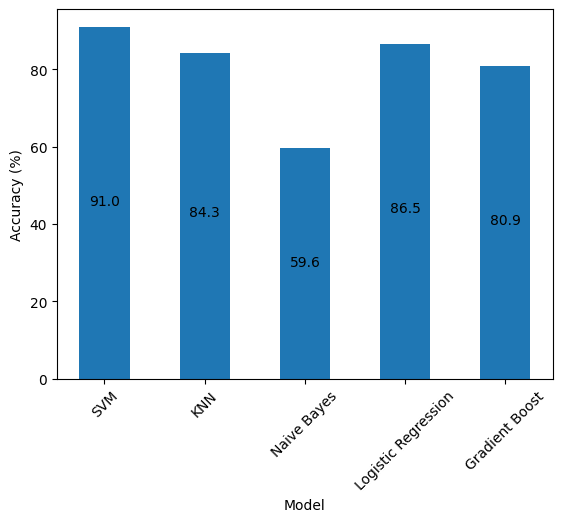

In [9]:
results.plot_acc(exact_accuracies)

# PCA

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

x = df.drop(columns=['volume', 'substance'])
y = df[['substance', 'volume']]

x_train, x_test, y_train, y_test = models.make_split(x, y, 42)

pca = PCA(n_components=0.9)
x_train_pca = pca.fit_transform(x_train)
x_test_pca  = pca.transform(x_test)

print("Original shape:", x_train.shape)
print("Reduced shape (PCA):", x_train_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

Original shape: (356, 308)
Reduced shape (PCA): (356, 32)
Explained variance ratio: [0.27639881 0.17132458 0.08286024 0.07232201 0.0513061  0.03345331
 0.02883018 0.02276553 0.01729872 0.01443299 0.01228483 0.01109204
 0.01027443 0.00891402 0.00824192 0.00753246 0.00653136 0.00647801
 0.00590711 0.00549385 0.00530775 0.00494749 0.00470278 0.00431456
 0.00411925 0.00403712 0.00396411 0.00373291 0.00362502 0.00347385
 0.00327264 0.00311415]
Total explained variance: 0.9023541106584223


C:\Users\chloe\AppData\Local\Temp\ipykernel_26340\1417016127.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x = df.drop(columns=['volume', 'substance'])


In [11]:
from src.models import multioutput_models
from sklearn.metrics import confusion_matrix
from sklearn.base import clone

label_names = ['Substance', 'Volume']

def train_models(x_train, x_test, y_train, y_test, substance_names, show_cm=False):
    acc = []
    per_label_acc = []
    
    models_copy = [[name, clone(model)] for name, model in multioutput_models]

    substance_labels = [
        (k[5:] if k.lower().startswith('redu ') else k).capitalize()
        for k in substance_names.keys()
    ]
    
    for model in models_copy:
        model[1].fit(x_train, y_train)
        y_pred = model[1].predict(x_test)
    
        # Exact match accuracy (all labels correct)
        exact_match_accuracy = np.mean(np.all(y_test.values == y_pred, axis=1))
    
        # Per-label accuracy
        per_label_accuracy = (y_test == y_pred).mean(axis=0)
    
        acc.append(exact_match_accuracy * 100)
        per_label_acc.append(per_label_accuracy * 100)
    
        # Confusion matrices for each label
        if show_cm:
            for i, col in enumerate(y_test.columns):
                cm = confusion_matrix(y_test.iloc[:, i], y_pred[:, i], normalize='true')

                if i == 0:
                    plt.figure(figsize=(8, 6))
                    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=substance_labels, yticklabels=substance_labels)
                    plt.xticks(rotation=45, ha='right')
                else:
                    plt.figure(figsize=(4, 3))
                    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues')
                
                plt.yticks(rotation=0)
                
                plt.title(f'{model[0]} Confusion Matrix, {label_names[i]}')
                plt.xlabel('Predicted Label')
                plt.ylabel('True Label')
                plt.show()


    return acc, per_label_acc

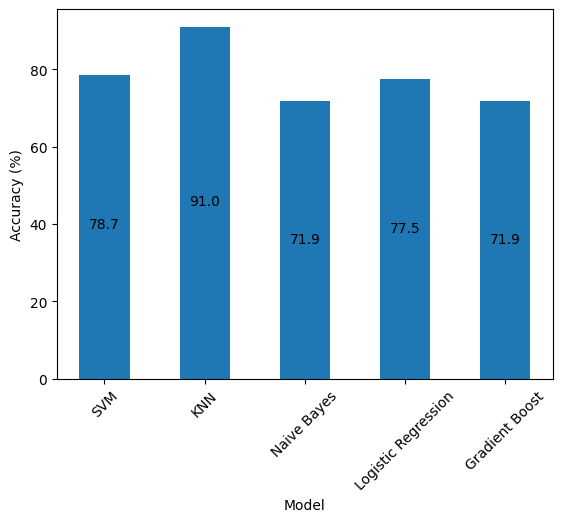

In [12]:
pca_accuracies, pca_label_accuracies = train_models(x_train_pca, x_test_pca, y_train, y_test, class_map)

results.plot_acc(pca_accuracies)

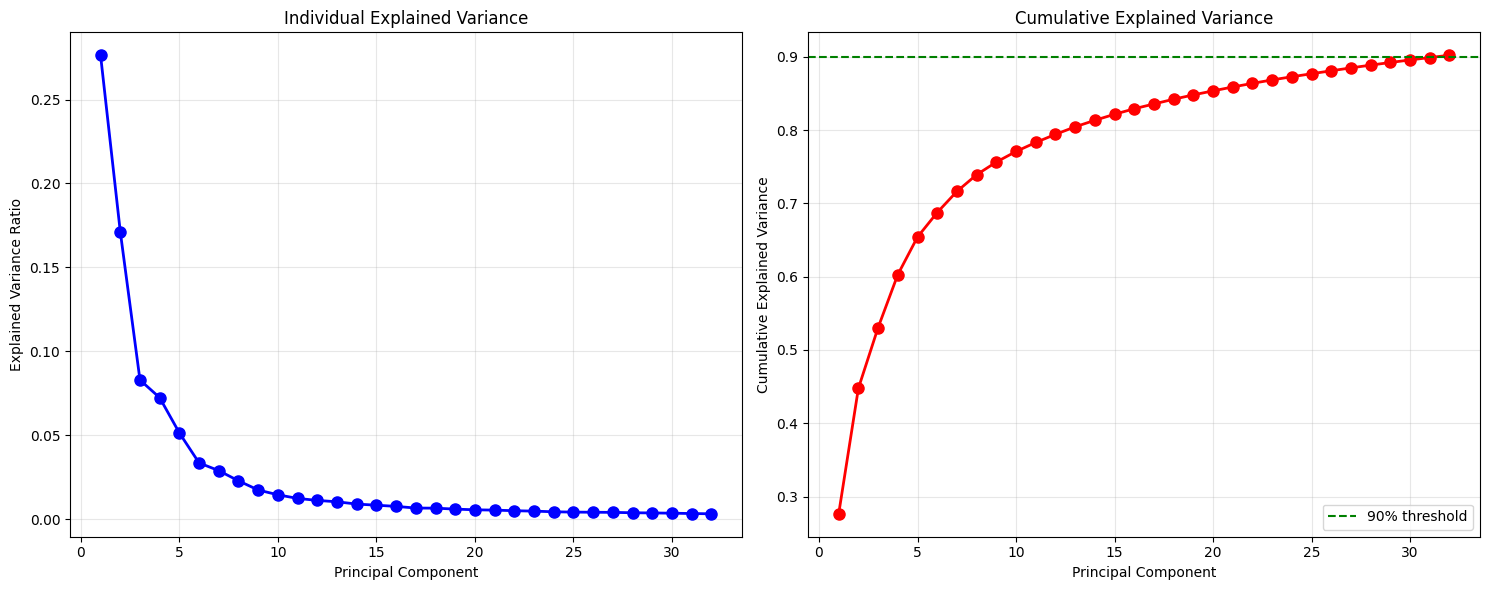

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Individual explained variance
ax1.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Individual Explained Variance')
ax1.grid(True, alpha=0.3)

# Cumulative explained variance
ax2.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 'ro-', linewidth=2, markersize=8)
ax2.axhline(y=0.9, color='g', linestyle='--', label='90% threshold')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

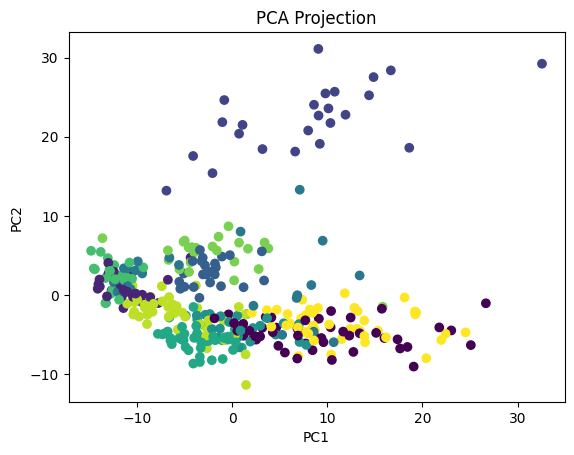

In [14]:
import matplotlib.pyplot as plt

plt.scatter(x_train_pca[:,0], x_train_pca[:,1], c=y_train['substance'], cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

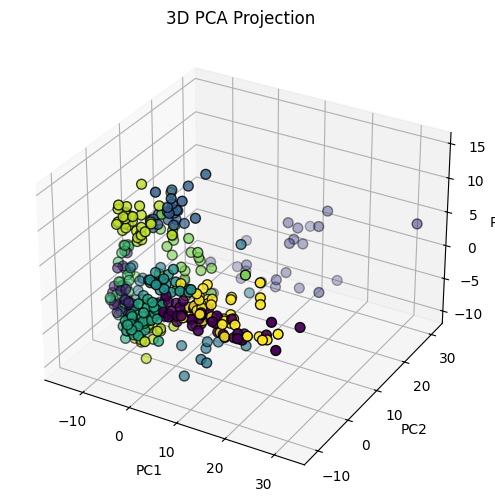

In [15]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# scatter plot in 3D
ax.scatter(
    x_train_pca[:,0], x_train_pca[:,1], x_train_pca[:,2],
    c=y_train['substance'], cmap='viridis', edgecolor='k', s=50
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection")

plt.show()